In [54]:
import pandas as pd
import wandb

In [94]:
RUN_PATH = "amanda-mendes-cloudwalk/diffusion-finetune/5qfga8ko"

In [95]:
run = wandb.Api().run(RUN_PATH)


In [96]:
df_norm = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_norm/t={t}" for t in range(48)])))
df_mean = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_mean/t={t}" for t in range(48)])))
df_std = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_std/t={t}" for t in range(48)])))

In [97]:
# Save dataframes to CSV files
df_norm.to_csv("gradient_norm_data.csv", index=False)
df_mean.to_csv("gradient_mean_data.csv", index=False)
df_std.to_csv("gradient_std_data.csv", index=False)

print("Saved dataframes to CSV files:")
print("- gradient_norm_data.csv")
print("- gradient_mean_data.csv")
print("- gradient_std_data.csv")


Saved dataframes to CSV files:
- gradient_norm_data.csv
- gradient_mean_data.csv
- gradient_std_data.csv


In [3]:
import pandas as pd
df_norm = pd.read_csv("gradient_norm_data.csv")
df_mean = pd.read_csv("gradient_mean_data.csv")
df_std = pd.read_csv("gradient_std_data.csv")

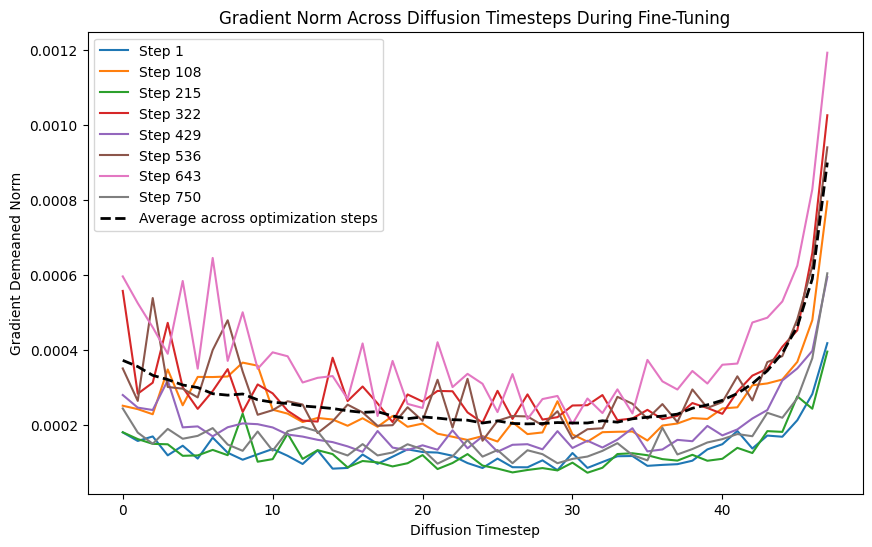

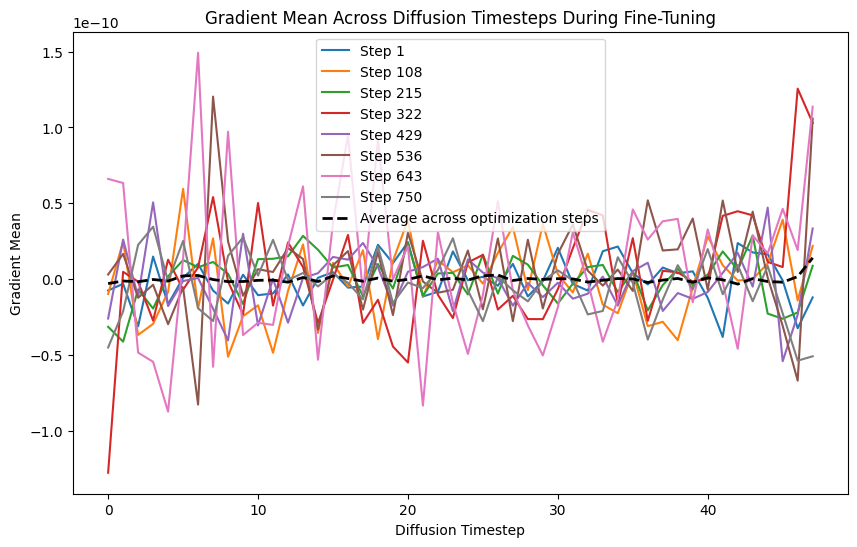

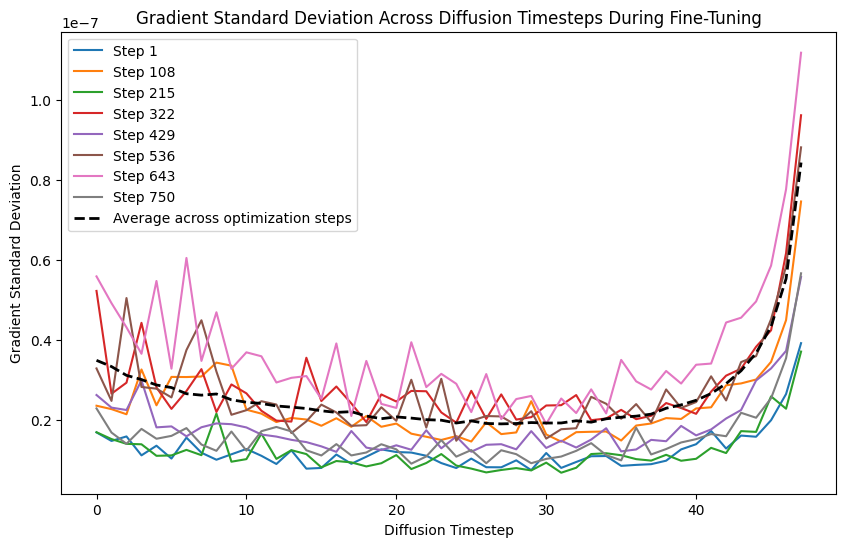

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample 5 uniformly distributed optimization steps 
opt_steps = np.linspace(0, len(df_norm)-1, 8, dtype=int)
diffusion_timesteps = [int(c.split("=")[1]) for c in df_norm.columns if "t=" in c]

# Define dataframes and their corresponding labels
dataframes = [
    (df_norm, "Gradient Demeaned Norm", "Gradient Norm Across Diffusion Timesteps During Fine-Tuning"),
    (df_mean, "Gradient Mean", "Gradient Mean Across Diffusion Timesteps During Fine-Tuning"),
    (df_std, "Gradient Standard Deviation", "Gradient Standard Deviation Across Diffusion Timesteps During Fine-Tuning")
]

# Create plots for each dataframe
for df, ylabel, title in dataframes:
    plt.figure(figsize=(10, 6))
    
    # Plot sample optimization steps
    for step in opt_steps:
        plt.plot(diffusion_timesteps, df.iloc[step], label=f"Step {step+1}")
    
    # Add the average across all steps (one value per timestep)
    gradient_cols = [col for col in df.columns if "t=" in col]
    average_across_steps = df[gradient_cols].mean(axis=0)
    plt.plot(diffusion_timesteps, average_across_steps, 'k--', linewidth=2, label="Average across optimization steps")
    
    plt.xlabel("Diffusion Timestep")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

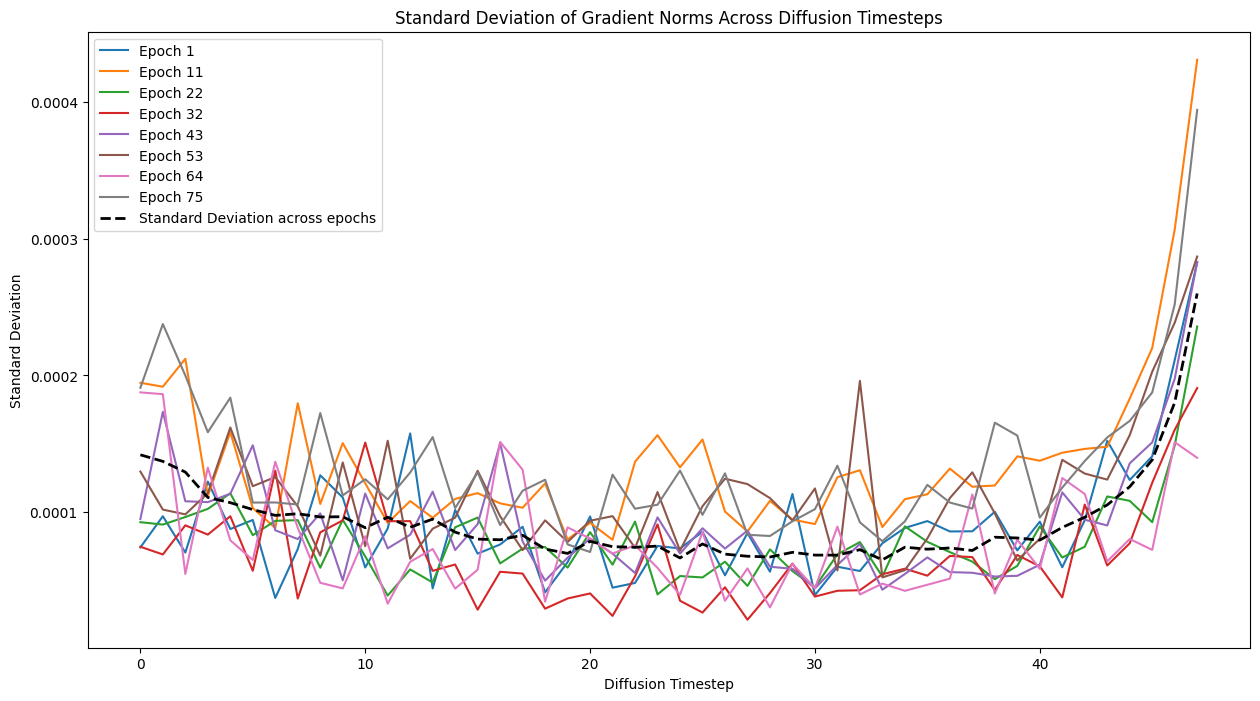

In [13]:
# Group every 5 rows and plot std for each epoch
epoch_size = 10
num_epochs = len(df_norm) // epoch_size

plt.figure(figsize=(15, 8))

# Sample 5 epochs uniformly distributed
epoch_indices = np.linspace(0, num_epochs-1, 8, dtype=int)

for i in epoch_indices:
    start_idx = i * epoch_size
    end_idx = start_idx + epoch_size
    epoch_data = df_norm.iloc[start_idx:end_idx]
    
    # Calculate std for this epoch and plot
    epoch_std = epoch_data.std()
    diffusion_timesteps = [int(c.split("=")[1]) for c in epoch_std.index if "t=" in c]
    gradient_cols = [col for col in epoch_std.index if "t=" in col]
    
    plt.plot(diffusion_timesteps, epoch_std[gradient_cols], label=f"Epoch {i+1}")

gradient_cols = [col for col in df_norm.columns if "t=" in col]
std_across_steps = df_norm[gradient_cols].std(axis=0)
plt.plot(diffusion_timesteps, std_across_steps, 'k--', linewidth=2, label="Standard Deviation across epochs")

plt.xlabel("Diffusion Timestep")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation of Gradient Norms Across Diffusion Timesteps")
plt.legend()
plt.show()

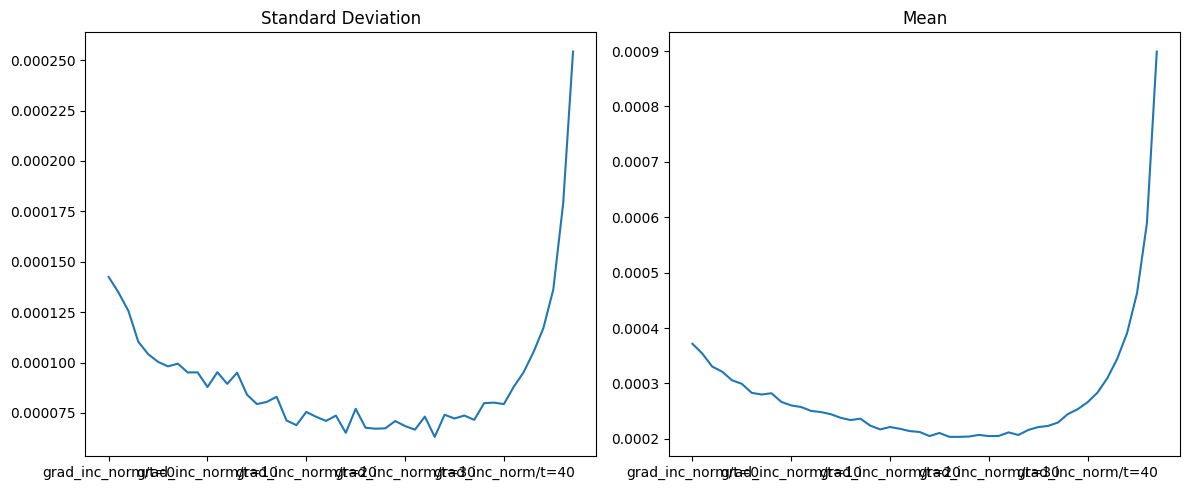

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_norm.std().plot(ax=ax1)
ax1.set_title("Standard Deviation")

df_norm.mean().plot(ax=ax2)
ax2.set_title("Mean")

plt.tight_layout()
plt.show()

In [18]:
1e6*df_std**2

,grad_inc_std/t=0,grad_inc_std/t=1,grad_inc_std/t=2,grad_inc_std/t=3,grad_inc_std/t=4,grad_inc_std/t=5,grad_inc_std/t=6,grad_inc_std/t=7,grad_inc_std/t=8,grad_inc_std/t=9,...,grad_inc_std/t=38,grad_inc_std/t=39,grad_inc_std/t=40,grad_inc_std/t=41,grad_inc_std/t=42,grad_inc_std/t=43,grad_inc_std/t=44,grad_inc_std/t=45,grad_inc_std/t=46,grad_inc_std/t=47
0,2.853958e-10,2.175325e-10,2.521649e-10,1.242760e-10,1.839093e-10,1.069842e-10,2.427984e-10,1.392546e-10,1.010304e-10,1.302169e-10,...,9.624424e-11,1.597131e-10,1.942313e-10,2.976990e-10,1.652736e-10,2.590306e-10,2.498047e-10,3.975900e-10,7.015221e-10,1.538165e-09
1,3.723468e-10,2.537776e-10,3.773943e-10,1.230794e-10,2.460076e-10,1.886430e-10,1.812248e-10,1.844176e-10,2.862272e-10,4.309174e-10,...,1.789280e-10,1.882079e-10,1.454708e-10,2.825583e-10,5.774136e-10,3.978252e-10,3.794976e-10,8.684877e-10,9.511854e-10,2.511442e-09
2,3.288436e-10,6.566728e-10,4.496841e-10,7.643464e-10,4.535313e-10,2.754823e-10,3.295830e-10,7.552346e-10,1.014264e-09,2.127979e-10,...,2.242360e-10,4.448634e-10,3.937004e-10,3.399632e-10,4.472974e-10,1.097536e-09,7.103060e-10,1.126132e-09,1.671143e-09,3.958452e-09
3,5.541236e-10,1.158541e-09,6.032690e-10,6.062179e-10,4.292018e-10,1.098390e-09,3.895258e-10,5.347169e-10,1.813393e-09,7.330027e-10,...,8.369200e-10,7.116942e-10,8.523811e-10,6.244596e-10,1.120237e-09,1.503570e-09,1.463252e-09,2.247354e-09,4.349831e-09,8.106413e-09
4,1.263802e-09,9.439237e-10,1.101944e-09,1.441820e-09,1.180098e-09,6.797140e-10,4.890675e-10,8.216506e-10,6.830270e-10,1.493306e-09,...,1.030722e-09,8.180176e-10,1.101864e-09,9.566961e-10,1.266059e-09,2.907144e-09,1.992098e-09,2.860918e-09,5.437392e-09,1.162666e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,2.534528e-09,5.721955e-09,3.450795e-09,1.950069e-09,3.724633e-09,1.595190e-09,1.451786e-09,1.134870e-09,1.699065e-09,1.996102e-09,...,2.695246e-09,2.554281e-09,1.319805e-09,1.437734e-09,2.071913e-09,2.262766e-09,3.167285e-09,3.805582e-09,8.765378e-09,1.961104e-08
746,3.989486e-09,1.646770e-09,2.159816e-09,2.267487e-09,9.117938e-10,8.438783e-10,1.707517e-09,1.220401e-09,2.933542e-09,1.605846e-09,...,6.174264e-10,1.045605e-09,1.141512e-09,1.693494e-09,1.592429e-09,2.796168e-09,2.561421e-09,2.401870e-09,4.096636e-09,1.262594e-08
747,3.899552e-10,5.141711e-10,1.956328e-10,1.562487e-10,3.041875e-10,2.779690e-10,3.412689e-10,2.026671e-10,3.436145e-10,4.879331e-10,...,1.163349e-10,1.790140e-10,3.135599e-10,2.457040e-10,2.938253e-10,3.179051e-10,4.494078e-10,5.665101e-10,1.233132e-09,2.035946e-09
748,9.940636e-10,1.687005e-09,1.294334e-09,8.127424e-10,9.325842e-10,1.113165e-09,9.154099e-10,7.349293e-10,9.351220e-10,9.991633e-10,...,5.876166e-10,9.070819e-10,8.811175e-10,9.047616e-10,1.407314e-09,1.321516e-09,1.850184e-09,3.768173e-09,5.094115e-09,8.889653e-09


In [ ]:
1e6*df_mean+1e6*df_std

,grad_inc_mean/t=0,grad_inc_mean/t=1,grad_inc_mean/t=10,grad_inc_mean/t=11,grad_inc_mean/t=12,grad_inc_mean/t=13,grad_inc_mean/t=14,grad_inc_mean/t=15,grad_inc_mean/t=16,grad_inc_mean/t=17,...,grad_inc_std/t=43,grad_inc_std/t=44,grad_inc_std/t=45,grad_inc_std/t=46,grad_inc_std/t=47,grad_inc_std/t=5,grad_inc_std/t=6,grad_inc_std/t=7,grad_inc_std/t=8,grad_inc_std/t=9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
result = 1e6 * df_mean + 1e6 * df_std
